In [254]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import ast
import json
import os

# Translation Table

NB: HERE WE WORK ONLY WITH ARTICLES WHICH HAVE FULL-TEXT -> CAN IMPACT THE NUMBER OF REPORTED ENTITIES. IF THEY HAD NO STUDIES WITH ANNOTATIONS, THEY ARE EXCLUDED

In [255]:
translation_table = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease.csv") # from Translation_02_Drug_Disease

In [256]:
translation_table.shape

(13570, 29)

In [257]:
13570+2253

15823

In [258]:
5899+2253

8152

### NB: current implementation does not add FDA only rows!!! would be + 2253 for translated -> 15823 as in table 3 (see Translation 2)

In [259]:
keep_linked_only = False
if keep_linked_only:
    # Filter to keep rows where both IDs are NOT -1
    translation_table = translation_table[
        (translation_table['merged_mondo_termid'] != "-1") & 
        (translation_table['merged_umls_termid'] != "-1")
    ]
    
    # Reset index for a clean dataframe
    translation_table = translation_table.reset_index(drop=True)

In [260]:
translation_table.shape

(13570, 29)

In [261]:
n_diseases = translation_table["merged_mondo_label"].nunique()
n_drugs = translation_table["merged_umls_label"].nunique()

print("\n=== Entity coverage summary ===")
print(f"Total unique diseases: {n_diseases:,}")
print(f"Total unique drugs: {n_drugs:,}")



=== Entity coverage summary ===
Total unique diseases: 1,383
Total unique drugs: 2,818


In [262]:
translation_table.head()

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,at_least_one_phase3_completed,at_least_one_phase4,trial_completion_year_first_completed_phase3,fda_merged_umls_label,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP
0,parkinson disease <> levodopa,"['NCT00004576', 'NCT00006077', 'NCT00006337', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 2000.0, 2000.0, 2001.0, 2001.0, 2002....","[2000.0, 2003.0, 2002.0, 2003.0, 2005.0, 2005....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2003.0,Levodopa,Parkinson disease,1975.0,parkinson's disease; parkinson’s disease,"['ANDA073589', 'ANDA073607', 'ANDA073618', 'AN...",parkinson disease <> levodopa,True
1,schizophrenia <> risperidone,"['NCT00014001', 'NCT00018668', 'NCT00034749', ...",MONDO:0005090,C0073393,schizophrenia,risperidone,"[2000.0, 2000.0, 2001.0, 2001.0, 2002.0, 2001....","[2004.0, 2004.0, 2006.0, 2002.0, 2005.0, 2002....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 3', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2000.0,Risperidone,schizophrenia,1993.0,schizophrenia,"['ANDA076440', 'ANDA077493', 'ANDA077494', 'AN...",schizophrenia <> risperidone,True
2,schizophrenia <> olanzapine,"['NCT00014001', 'NCT00034801', 'NCT00034892', ...",MONDO:0005090,C0171023,schizophrenia,olanzapine,"[2000.0, 2001.0, 2002.0, 2001.0, 2001.0, 2001....","[2004.0, 2003.0, 2005.0, 2002.0, 2003.0, 2006....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 4', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2002.0,OLANZapine,schizophrenia,1996.0,schizophrenia,"['ANDA076133', 'ANDA076255', 'ANDA076534', 'AN...",schizophrenia <> olanzapine,True
3,schizophrenia <> aripiprazole,"['NCT00036127', 'NCT00036361', 'NCT00080327', ...",MONDO:0005090,C0299792,schizophrenia,aripiprazole,"[2002.0, 2002.0, 2003.0, 2003.0, 2004.0, 2004....","[2003.0, 2003.0, 2004.0, 2007.0, 2006.0, 2005....","['Phase 2/Phase 3', 'Phase 3', 'Phase 4', 'Pha...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2003.0,ARIPiprazole,schizophrenia,2002.0,schizophrenia,"['ANDA201519', 'ANDA202101', 'ANDA202102', 'AN...",schizophrenia <> aripiprazole,True
4,depressive disorder <> antidepressant,"['NCT00009191', 'NCT00018902', 'NCT00026637', ...",MONDO:0002050,-1,depressive disorder,antidepressant,"[2005.0, 2001.0, 2001.0, 2002.0, 2004.0, 2004....","[2007.0, 2007.0, 2008.0, 2006.0, 2009.0, 2014....","['Phase 4', 'Phase 2/Phase 3', 'Phase 3', 'Pha...","['Completed', 'Completed', 'Completed', 'Compl...",...,True,True,2004.0,NaN,NaN,NaN,NaN,NaN,NaN,False


In [263]:
translation_table.normalized_key.nunique()

13570

### translated

In [264]:
translation_table["translation_status"] = np.where(
    (
        translation_table["at_least_one_phase4"]
        | translation_table["at_least_one_phase3_completed"]
        | translation_table["fda_AP"]
    ),
    "approved",
    "failed",
)
print("=== Translation status summary ===")
print(translation_table["translation_status"].value_counts())
print()

=== Translation status summary ===
translation_status
failed      7671
approved    5899
Name: count, dtype: int64



In [265]:
translation_table["min_relevant_clinical_year"] = (
    translation_table[
        [
            "min_phase_4_year",
            "trial_completion_year_first_completed_phase3",
            "fda_earliest_year",
        ]
    ]
    .min(axis=1, skipna=True)
)
translation_table["min_relevant_clinical_year"] = (
    translation_table["min_relevant_clinical_year"]
    .round()
    .astype("Int64")   # nullable integer dtype
)


In [266]:
df_translated = translation_table[translation_table['translation_status']=="approved"]
df_translated.shape

(5899, 31)

In [267]:

def to_list(x):
    if not isinstance(x, str) or not x.startswith('['):
        return x if isinstance(x, list) else []
    
    # Replace 'nan' with 'None' so the parser understands it
    cleaned_x = x.replace('nan', 'None')
    
    try:
        return ast.literal_eval(cleaned_x)
    except Exception as e:
        # If literal_eval still fails, try json.loads as a backup
        try:
            return json.loads(cleaned_x.replace("'", '"'))
        except:
            print(f"Failed to parse: {x[:50]}...") # Print first 50 chars of error
            return []

# Apply the fix
df_translated.loc[:, 'preclinical_doc_ids'] = df_translated['preclinical_doc_ids'].apply(to_list)
df_translated.loc[:, 'pub_year'] = df_translated['pub_year'].apply(to_list)

df_translated.head(2)

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,trial_completion_year_first_completed_phase3,fda_merged_umls_label,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,translation_status,min_relevant_clinical_year
0,parkinson disease <> levodopa,"['NCT00004576', 'NCT00006077', 'NCT00006337', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 2000.0, 2000.0, 2001.0, 2001.0, 2002....","[2000.0, 2003.0, 2002.0, 2003.0, 2005.0, 2005....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,2003.0,Levodopa,Parkinson disease,1975.0,parkinson's disease; parkinson’s disease,"['ANDA073589', 'ANDA073607', 'ANDA073618', 'AN...",parkinson disease <> levodopa,True,approved,1975
1,schizophrenia <> risperidone,"['NCT00014001', 'NCT00018668', 'NCT00034749', ...",MONDO:0005090,C0073393,schizophrenia,risperidone,"[2000.0, 2000.0, 2001.0, 2001.0, 2002.0, 2001....","[2004.0, 2004.0, 2006.0, 2002.0, 2005.0, 2002....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 3', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,2000.0,Risperidone,schizophrenia,1993.0,schizophrenia,"['ANDA076440', 'ANDA077493', 'ANDA077494', 'AN...",schizophrenia <> risperidone,True,approved,1993


In [268]:
df_translated[df_translated['normalized_key']=='type 2 diabetes mellitus <> metformin']

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,trial_completion_year_first_completed_phase3,fda_merged_umls_label,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,translation_status,min_relevant_clinical_year
5117,type 2 diabetes mellitus <> metformin,['NCT02519543'],MONDO:0005148,C0025598,type 2 diabetes mellitus,metformin,[2015.0],[2020.0],['Phase 3'],['Completed'],...,2020.0,Metformin,type 2 diabetes mellitus,2002.0,type 2 diabetes mellitus,"['ANDA075965', 'ANDA075972', 'ANDA075973', 'AN...",type 2 diabetes mellitus <> metformin,True,approved,2002


In [269]:
df_translated['preclinical_ids_before_clinical'] = df_translated.apply(
    lambda row: [
        doc_id for doc_id, year in zip(row['preclinical_doc_ids'], row['pub_year']) 
        if pd.notnull(row['min_relevant_clinical_year']) and pd.notnull(year) and float(year) <= row['min_relevant_clinical_year']
    ], 
    axis=1
)
df_translated['preclinical_count_before_clinical'] = df_translated['preclinical_ids_before_clinical'].str.len()
df_translated.shape

/tmp/ipykernel_3939435/1590931843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['preclinical_ids_before_clinical'] = df_translated.apply(
/tmp/ipykernel_3939435/1590931843.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['preclinical_count_before_clinical'] = df_translated['preclinical_ids_before_clinical'].str.len()


(5899, 33)

In [270]:
translated_pmids = list(set([
    pmid 
    for sublist in df_translated['preclinical_ids_before_clinical'] 
    for pmid in sublist
]))
len(translated_pmids)

22246

In [271]:
translated_pmids[:5]

[9306115, 19660809, 21495821, 8912913, 23724049]

In [272]:
df_translated[df_translated.normalized_key.str.contains("parkinson disease <> levodopa")]

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,translation_status,min_relevant_clinical_year,preclinical_ids_before_clinical,preclinical_count_before_clinical
0,parkinson disease <> levodopa,"['NCT00004576', 'NCT00006077', 'NCT00006337', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 2000.0, 2000.0, 2001.0, 2001.0, 2002....","[2000.0, 2003.0, 2002.0, 2003.0, 2005.0, 2005....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,Parkinson disease,1975.0,parkinson's disease; parkinson’s disease,"['ANDA073589', 'ANDA073607', 'ANDA073618', 'AN...",parkinson disease <> levodopa,True,approved,1975,"[4279185, 123156, 1171223, 1152552]",4
45,late-onset parkinson disease <> levodopa,"['NCT00009048', 'NCT00013624', 'NCT00040209', ...",MONDO:0008199,C0023570,late-onset parkinson disease,levodopa,"[2001.0, 2001.0, 2002.0, 2004.0, 2004.0, 2005....","[2003.0, 2005.0, 2005.0, 2005.0, 2007.0, nan, ...","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,NaN,NaN,NaN,NaN,NaN,False,approved,2005,[],0
229,young-onset parkinson disease <> levodopa,"['NCT00096720', 'NCT00134784', 'NCT00134966', ...",MONDO:0017279,C0023570,young-onset parkinson disease,levodopa,"[2004.0, 2000.0, 2005.0, 2005.0, 2005.0, 2007....","[2007.0, 2007.0, 2007.0, 2009.0, 2008.0, 2012....","['Phase 2', 'Phase 2', 'Phase 3', 'Phase 4', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,NaN,NaN,NaN,NaN,NaN,False,approved,2005,"[16002472, 7915897]",2
3611,parkinson disease <> levodopa benserazide,"['NCT02741947', 'NCT06115538']",MONDO:0005180,-1,parkinson disease,levodopa benserazide,"[2014.0, 2023.0]","[2015.0, 2025.0]","['Phase 4', 'Phase 4']","['Completed', 'Enrolling by invitation']",...,NaN,NaN,NaN,NaN,NaN,False,approved,2014,"[8619541, 12524151, 14673879, 14526427, 173737...",6
9861,parkinson disease <> levodopa/benserazide,['NCT02741947'],MONDO:0005180,-1,parkinson disease,levodopa/benserazide,[2014.0],[2015.0],['Phase 4'],['Completed'],...,NaN,NaN,NaN,NaN,NaN,False,approved,2014,[25511986],1


### not translated (and not recently entered clinical)

In [273]:
df_failed = translation_table[translation_table['translation_status']=="failed"]
df_failed = df_failed[df_failed['min_trial_start_year']<2015]
df_failed.shape

(4252, 31)

In [274]:
7671-4252

3419

In [275]:
4252+5899+3419

13570

In [276]:
df_failed.loc[:, 'max_trial_start_year'] = pd.to_numeric(df_failed['max_trial_start_year'], errors='coerce')
df_failed.loc[:, 'preclinical_doc_ids'] = df_failed['preclinical_doc_ids'].apply(to_list)
df_failed.loc[:, 'pub_year'] = df_failed['pub_year'].apply(to_list)

In [277]:
df_failed["min_relevant_clinical_year"] = (
    df_failed["max_trial_start_year"]
    .round()
    .astype("Int64")   # nullable integer dtype
)

In [278]:
df_failed['preclinical_ids_before_latest_trial'] = df_failed.apply(
    lambda row: [
        doc_id for doc_id, year in zip(row['preclinical_doc_ids'], row['pub_year']) 
        if pd.notnull(row['max_trial_start_year']) and pd.notnull(year) and float(year) <= row['max_trial_start_year']
    ], 
    axis=1
)
df_failed['preclinical_count_before_latest_trial'] = df_failed['preclinical_ids_before_latest_trial'].str.len()
df_failed.shape

(4252, 33)

In [279]:
df_failed.head(5)

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_disease_mondo_term_norm,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,translation_status,min_relevant_clinical_year,preclinical_ids_before_latest_trial,preclinical_count_before_latest_trial
80,drug dependence <> cocaine,"['NCT00032916', 'NCT00033059', 'NCT00033098', ...",MONDO:0005303,C0009170,drug dependence,cocaine,"[2001.0, 2001.0, 2001.0, 2003.0, 2003.0, 2004....","[2002.0, 2002.0, 2002.0, 2005.0, nan, 2005.0, ...","['Phase 1', 'Phase 1', 'Phase 1', 'Phase 1', '...","['Unknown status', 'Unknown status', 'Unknown ...",...,NaN,NaN,NaN,NaN,NaN,False,failed,2018,"[21790900, 29227643, 10485969, 21206484, 15713...",35
98,cocaine dependence <> cocaine,"['NCT00032916', 'NCT00033059', 'NCT00033098', ...",MONDO:0005186,C0009170,cocaine dependence,cocaine,"[2001.0, 2001.0, 2001.0, 2003.0, 2003.0, 2004....","[2002.0, 2002.0, 2002.0, 2005.0, nan, 2005.0, ...","['Phase 1', 'Phase 1', 'Phase 1', 'Phase 1', '...","['Unknown status', 'Unknown status', 'Unknown ...",...,NaN,NaN,NaN,NaN,NaN,False,failed,2018,"[21790900, 29227643, 10485969, 21206484, 15713...",33
100,brain neoplasm <> temozolomide,"['NCT00005812', 'NCT00006024', 'NCT00034697', ...",MONDO:0021211,C0076080,brain neoplasm,temozolomide,"[2000.0, 2000.0, 2001.0, 2004.0, 2004.0, 2006....","[2004.0, 2006.0, 2003.0, 2006.0, 2013.0, 2014....","['Phase 2', 'Phase 1', 'Phase 2', 'Phase 2', '...","['Terminated', 'Completed', 'Terminated', 'Com...",...,NaN,NaN,NaN,NaN,NaN,False,failed,2023,"[25867026, 36353533, 26778701, 26673818, 31909...",122
221,brain neoplasm <> bevacizumab,"['NCT00312728', 'NCT00463203', 'NCT00597402', ...",MONDO:0021211,C0796392,brain neoplasm,bevacizumab,"[2006.0, 2007.0, 2007.0, 2008.0, 2008.0, 2009....","[2009.0, 2011.0, 2013.0, 2014.0, 2015.0, 2010....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 1', '...","['Completed', 'Completed', 'Completed', 'Termi...",...,NaN,NaN,NaN,NaN,NaN,False,failed,2020,"[21123368, 24980761, 26043866, 21187487, 24963...",9
244,obsolete disorder involving pain <> dronabinol,"['NCT00176163', 'NCT00552604', 'NCT01608217', ...",MONDO:0021668,C0039663,obsolete disorder involving pain,dronabinol,"[2005.0, 2006.0, 2012.0, 2015.0, 2020.0, 2021....","[2009.0, 2008.0, 2014.0, 2019.0, 2020.0, 2025....","['Phase 2', 'Phase 3', 'Phase 2', 'Not Applica...","['Completed', 'Terminated', 'Completed', 'Unkn...",...,NaN,NaN,NaN,NaN,NaN,False,failed,2023,"[30225659, 10696800, 17498686, 25790278, 22109...",29


In [280]:
failed_pmids = list(set([
    pmid 
    for sublist in df_failed['preclinical_ids_before_latest_trial'] 
    for pmid in sublist
]))
len(failed_pmids)

14030

# Preclinical annotations

In [281]:
def summarize_preclinical_retrieval(
    df_original,
    df_targets,
    df_retrieved,
    target_pmid_col="pmid",
    retrieved_pmid_col="PMID",
    key_col="normalized_key",
    relevant_preclin_cound_col="preclinical_count_before_clinical", #"preclinical_count_before_latest_trial",
    verbose=True,
):
    """
    Summarize retrieval coverage after joining target PMIDs to a preclinical dataset.
    """

    # --- PMID-level retrieval ---
    target_pmids = df_targets[target_pmid_col].nunique()
    retrieved_pmids = df_retrieved[retrieved_pmid_col].nunique()

    pct_pmids_retrieved = 100 * retrieved_pmids / target_pmids if target_pmids > 0 else 0.0

    # --- normalized_key-level coverage ---
    keys_before = set(df_targets[key_col].dropna())
    keys_after = set(df_retrieved[key_col].dropna())

    n_keys_before = len(keys_before)
    n_keys_after = len(keys_after)

    keys_with_no_articles = keys_before - keys_after
    n_keys_with_no_articles = len(keys_with_no_articles)

    pct_keys_retrieved = 100 * n_keys_after / n_keys_before if n_keys_before > 0 else 0.0
    pct_keys_missing = 100 * n_keys_with_no_articles / n_keys_before if n_keys_before > 0 else 0.0

    if verbose:
        print("\n" + "=" * 60)
        print("PRECLINICAL RETRIEVAL SUMMARY")
        print("=" * 60)

        # --- Target population ---
        print("\n[1] Target drug–disease pairs")
        target_entity_pairs = df_original[key_col].nunique()
        print(f"Total target pairs: {target_entity_pairs:,}")

        missing_before_clinical = (
            df_original[relevant_preclin_cound_col] == 0
        ).sum()
        print(
            f"Pairs with NO preclinical studies before clinical: "
            f"{missing_before_clinical:,} "
            f"({100 * missing_before_clinical / target_entity_pairs:.1f}%)"
        )
        print(
            f"Pairs with ≥1 preclinical study before clinical: "
            f"{target_entity_pairs - missing_before_clinical:,}"
        )

        # --- PMID retrieval ---
        print("\n[2] PMID-level retrieval")
        print(
            f"Target PMIDs:    {target_pmids:,}\n"
            f"Retrieved PMIDs: {retrieved_pmids:,}\n"
            f"Retrieval rate:  {pct_pmids_retrieved:.1f}%"
        )

        # --- normalized_key coverage ---
        print("\n[3] normalized_key coverage (entity-level)")
        print(
            f"Keys with ≥1 retrieved article: {n_keys_after:,} / {n_keys_before:,} "
            f"({pct_keys_retrieved:.1f}%)"
        )
        print(
            f"Keys with NO retrieved articles: {n_keys_with_no_articles:,} / {n_keys_before:,} "
            f"({pct_keys_missing:.1f}%)"
        )

        print("=" * 60 + "\n")


    return {
        "target_pmids": target_pmids,
        "retrieved_pmids": retrieved_pmids,
        "pct_pmids_retrieved": pct_pmids_retrieved,
        "n_keys_before": n_keys_before,
        "n_keys_after": n_keys_after,
        "n_keys_with_no_articles": n_keys_with_no_articles,
        "pct_keys_retrieved": pct_keys_retrieved,
        "pct_keys_missing": pct_keys_missing,
        "keys_with_no_articles": keys_with_no_articles,
    }


In [282]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv" #full_text_combined_all_annotations.csv" older version with less studies 340380. 'disease_term_mondo_norm','drug_term_umls_norm'
# ,'animal_age'
preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]
preclin_dataset['animal_sex'] = preclin_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))
#primekg_cleaned = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv")
#preclin_dataset = preclin_dataset.merge(primekg_cleaned[['PMID','merged_mondo_label','merged_umls_label']], on="PMID", how="left")

preclin_dataset.head()

/tmp/ipykernel_3939435/2323375893.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_strain','animal_number', 'assay_type', 'first_author_country']]


,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country
0,1000129,Effect of morphine and naloxone on priming-ind...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,BALB/C,not reported,not reported,unlabeled
1,1000338,A morphometric investigation of the duodenal m...,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,Sprague-Dawley,not reported,"Histology, Molecular & Cellular",unlabeled
2,10021294,Effects of IL-12 on human ovarian tumors engra...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,45.0,not reported,USA
3,10021348,Mechanisms of GDF-5 action during skeletal dev...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"Histology, Molecular & Cellular",UK
4,10022166,Prenatal vitamin E treatment improves lung gro...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,female,Sprague-Dawley,not reported,"Histology, Molecular & Cellular",USA


In [283]:
preclin_dataset.shape

(371832, 12)

### translated subset

In [284]:
df_translated_rel = df_translated[['normalized_key', 'preclinical_ids_before_clinical','merged_mondo_label','merged_umls_label']]

# Explode the list column into individual rows
df_translated_exploded = df_translated_rel.explode('preclinical_ids_before_clinical')
df_translated_exploded = df_translated_exploded.reset_index(drop=True)
df_translated_exploded = df_translated_exploded.rename(columns={'preclinical_ids_before_clinical': 'pmid'})

df_translated_exploded = df_translated_exploded.dropna(subset=['pmid'])
df_translated_exploded.head()

,normalized_key,pmid,merged_mondo_label,merged_umls_label
0,parkinson disease <> levodopa,4279185,parkinson disease,levodopa
1,parkinson disease <> levodopa,123156,parkinson disease,levodopa
2,parkinson disease <> levodopa,1171223,parkinson disease,levodopa
3,parkinson disease <> levodopa,1152552,parkinson disease,levodopa
4,schizophrenia <> risperidone,7510574,schizophrenia,risperidone


In [285]:
df_translated_exploded[df_translated_exploded.normalized_key.str.contains("parkinson disease <> levodopa")]

,normalized_key,pmid,merged_mondo_label,merged_umls_label
0,parkinson disease <> levodopa,4279185,parkinson disease,levodopa
1,parkinson disease <> levodopa,123156,parkinson disease,levodopa
2,parkinson disease <> levodopa,1171223,parkinson disease,levodopa
3,parkinson disease <> levodopa,1152552,parkinson disease,levodopa
2439,young-onset parkinson disease <> levodopa,16002472,young-onset parkinson disease,levodopa
2440,young-onset parkinson disease <> levodopa,7915897,young-onset parkinson disease,levodopa
21716,parkinson disease <> levodopa benserazide,8619541,parkinson disease,levodopa benserazide
21717,parkinson disease <> levodopa benserazide,12524151,parkinson disease,levodopa benserazide
21718,parkinson disease <> levodopa benserazide,14673879,parkinson disease,levodopa benserazide
21719,parkinson disease <> levodopa benserazide,14526427,parkinson disease,levodopa benserazide


In [286]:
df_translated_exploded.normalized_key.nunique()

3880

In [287]:
filtered_preclin_df_translated = pd.merge(
    df_translated_exploded, 
    preclin_dataset, 
    left_on='pmid', 
    right_on='PMID', 
    how='inner'
)

# 3. Clean up
# Since we have both 'pmid' and 'PMID' columns now, we can drop the lowercase one
filtered_preclin_df_translated = filtered_preclin_df_translated.drop(columns=['pmid']).reset_index(drop=True)


In [288]:
stats = summarize_preclinical_retrieval(
    df_translated,
    df_translated_exploded,
    filtered_preclin_df_translated,
)



PRECLINICAL RETRIEVAL SUMMARY

[1] Target drug–disease pairs
Total target pairs: 5,899
Pairs with NO preclinical studies before clinical: 2,019 (34.2%)
Pairs with ≥1 preclinical study before clinical: 3,880

[2] PMID-level retrieval
Target PMIDs:    22,246
Retrieved PMIDs: 13,242
Retrieval rate:  59.5%

[3] normalized_key coverage (entity-level)
Keys with ≥1 retrieved article: 3,121 / 3,880 (80.4%)
Keys with NO retrieved articles: 759 / 3,880 (19.6%)



In [289]:
filtered_preclin_df_translated['study_classification'] = "approved"

filtered_preclin_df_translated.head()

,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification
0,schizophrenia <> risperidone,schizophrenia,risperidone,2471220,"Risperidone (R 64 766), a potent and complete ...",blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,male,Wistar,15.0,Molecular & Cellular,Belgium,approved
1,schizophrenia <> olanzapine,schizophrenia,olanzapine,8935801,Risperidone compared with new and reference an...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"guinea pig, rat",not-reported,not reported,not reported,Molecular & Cellular,Belgium,approved
2,schizophrenia <> paliperidone,schizophrenia,paliperidone,8935801,Risperidone compared with new and reference an...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"guinea pig, rat",not-reported,not reported,not reported,Molecular & Cellular,Belgium,approved
3,schizophrenia <> quetiapine,schizophrenia,quetiapine,8935801,Risperidone compared with new and reference an...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"guinea pig, rat",not-reported,not reported,not reported,Molecular & Cellular,Belgium,approved
4,schizophrenia <> ziprasidone,schizophrenia,ziprasidone,8935801,Risperidone compared with new and reference an...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"guinea pig, rat",not-reported,not reported,not reported,Molecular & Cellular,Belgium,approved


In [290]:
filtered_preclin_df_translated[filtered_preclin_df_translated.normalized_key.str.contains("parkinson disease <> levodopa")]

,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification
2018,young-onset parkinson disease <> levodopa,young-onset parkinson disease,levodopa,7915897,Genetic linkage studies in autosomal dominant ...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,cat,both,not reported,not reported,Physiology,USA,approved
3860,parkinson disease <> levodopa/benserazide,parkinson disease,levodopa/benserazide,25511986,Levodopa/benserazide microsphere (LBM) prevent...,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,female,Sprague-Dawley,48.0,"Behavioral, Imaging, Molecular & Cellular",China,approved
4510,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,12524151,Motor effects of a dopamine stabilizer (GMC111...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,monkey,both,not reported,"[18.0, 6.0, 12.0]",Molecular & Cellular,Sweden,approved
9223,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,14673879,Chronic treatment with small doses of cabergol...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,monkey,female,not reported,8.0,not reported,Canada,approved
13551,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,14526427,Effect of levodopa chronic administration on b...,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,male,Sprague-Dawley,60.0,"Behavioral, Histology, Molecular & Cellular",China,approved
13552,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,17373723,Antiparkinsonian activity of L-propyl-L-leucyl...,blinding-present,randomization-present,welfare-present,sample-size-not-reported,"dog, monkey",male,not reported,6.0,Behavioral,UK,approved
13553,parkinson disease <> levodopa benserazide,parkinson disease,levodopa benserazide,8925275,Reversal of levodopa-induced motor fluctuation...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,Sprague-Dawley,not reported,"Histology, Molecular & Cellular",USA,approved


### failed subset

In [291]:
docs_col = "preclinical_ids_before_latest_trial"
df_failed_rel = df_failed[['normalized_key', docs_col, 'merged_mondo_label','merged_umls_label']] #preclinical_doc_ids

# Explode the list column into individual rows
df_failed_exploded = df_failed_rel.explode(docs_col)
df_failed_exploded = df_failed_exploded.reset_index(drop=True)
df_failed_exploded = df_failed_exploded.rename(columns={docs_col: 'pmid'})

df_failed_exploded = df_failed_exploded.dropna(subset=['pmid'])
df_failed_exploded.head()

,normalized_key,pmid,merged_mondo_label,merged_umls_label
0,drug dependence <> cocaine,21790900,drug dependence,cocaine
1,drug dependence <> cocaine,29227643,drug dependence,cocaine
2,drug dependence <> cocaine,10485969,drug dependence,cocaine
3,drug dependence <> cocaine,21206484,drug dependence,cocaine
4,drug dependence <> cocaine,15713268,drug dependence,cocaine


In [292]:
filtered_preclin_df_failed = pd.merge(
    df_failed_exploded, 
    preclin_dataset, 
    left_on='pmid', 
    right_on='PMID', 
    how='inner'
)

# 3. Clean up
# Since we have both 'pmid' and 'PMID' columns now, we can drop the lowercase one
filtered_preclin_df_failed = filtered_preclin_df_failed.drop(columns=['pmid']).reset_index(drop=True)
filtered_preclin_df_failed['study_classification'] = "failed"

print(f"Total rows after joining with PMIDs: {len(filtered_preclin_df_failed)} / {filtered_preclin_df_failed.PMID.nunique()}")

Total rows after joining with PMIDs: 10799 / 8790


In [293]:
stats = summarize_preclinical_retrieval(
    df_failed,
    df_failed_exploded,
    filtered_preclin_df_failed,
    relevant_preclin_cound_col="preclinical_count_before_latest_trial"
)



PRECLINICAL RETRIEVAL SUMMARY

[1] Target drug–disease pairs
Total target pairs: 4,252
Pairs with NO preclinical studies before clinical: 1,579 (37.1%)
Pairs with ≥1 preclinical study before clinical: 2,673

[2] PMID-level retrieval
Target PMIDs:    14,030
Retrieved PMIDs: 8,790
Retrieval rate:  62.7%

[3] normalized_key coverage (entity-level)
Keys with ≥1 retrieved article: 2,110 / 2,673 (78.9%)
Keys with NO retrieved articles: 563 / 2,673 (21.1%)



### concat

In [294]:
# Append the translated rows to the failed rows
combined_preclin_df = pd.concat([filtered_preclin_df_failed, filtered_preclin_df_translated], axis=0)

# Highly recommended: Reset the index
combined_preclin_df = combined_preclin_df.reset_index(drop=True)

In [295]:
combined_preclin_df.shape

(29562, 16)

In [296]:
# Count how many PMID values are repeated
duplicate_count = combined_preclin_df.duplicated(subset=['PMID']).sum()

print(f"Number of duplicate PMIDs: {duplicate_count}")

Number of duplicate PMIDs: 8932


In [297]:
combined_preclin_df.head()

,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification
0,drug dependence <> cocaine,drug dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,Swiss,"[22.0, 27.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,failed
1,cocaine dependence <> cocaine,cocaine dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,Swiss,"[22.0, 27.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,failed
2,drug dependence <> cocaine,drug dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,failed
3,cocaine dependence <> cocaine,cocaine dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,failed
4,drug dependence <> cocaine,drug dependence,cocaine,10485969,Rapid induction of behavioral and neurochemica...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,not reported,not reported,Molecular & Cellular,USA,failed


In [298]:
def get_unique_drug_disease(df):
    n_diseases = df["merged_mondo_label"].nunique()
    n_drugs = df["merged_umls_label"].nunique()
    
    print("\n=== Entity coverage summary ===")
    print(f"Total unique diseases: {n_diseases:,}")
    print(f"Total unique drugs: {n_drugs:,}")

In [299]:
get_unique_drug_disease(filtered_preclin_df_translated)


=== Entity coverage summary ===
Total unique diseases: 582
Total unique drugs: 965


In [300]:
get_unique_drug_disease(filtered_preclin_df_failed)


=== Entity coverage summary ===
Total unique diseases: 458
Total unique drugs: 834


In [301]:
get_unique_drug_disease(combined_preclin_df)


=== Entity coverage summary ===
Total unique diseases: 767
Total unique drugs: 1,425


# Translation stats

In [302]:
def to_pct(val):
    if pd.isna(val):
        return np.nan
    # already numeric: assume 0–1 are proportions, >=1 are percent values
    if isinstance(val, (int, float)):
        return float(val) * 100 if 0 <= float(val) <= 1 else float(val)
    s = str(val).strip()
    # match "(40.0%)" inside text like "6 (40.0%)"
    m = re.search(r'\(([-+]?\d*\.?\d+)\s*%?\)', s)
    if m:
        return float(m.group(1))
    # match trailing "40%" or "40.0 %"
    m = re.search(r'([-+]?\d*\.?\d+)\s*%$', s)
    if m:
        return float(m.group(1))
    # fallback: try raw float
    try:
        return float(s)
    except ValueError:
        return np.nan

In [303]:
_splitter = re.compile(r'[|,]')

def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x


def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        if 'female' in t:    out.add('female')
        if 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out
    
def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other','not reported'})  # exclude species-other
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled', 'not reported'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled', 'not reported'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled','not reported'})
    articles = _clean_set(row.get('PMID'))

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),
        'articles_count': int(len(articles))
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"
    
def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}
    
def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''



def get_heterogeneity_stats(df, agg_dict, drug_col_name, study_id_col="PMID"):

    table_by_drug = (df
      .groupby(drug_col_name, dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={drug_col_name: 'drug_name'}))

    # flags + aggregates for non-approved
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)
    total_drugs = len(table_by_drug)
    
    aggregate_stats = pd.Series({
        'n_entities_in_table': total_drugs,
        'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags['tested_both_sexes'].sum()), total_drugs),
        'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags['species_ge2'].sum()), total_drugs),
        'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags['strains_ge2'].sum()), total_drugs),
        'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags['assays_ge2'].sum()), total_drugs),
        'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags['countries_ge2'].sum()), total_drugs),
    })
    
    # study-level totals & rigor % for the filtered non-approved subset (unique studies only)
    total_studies_non = int(df[study_id_col].nunique())
    aggregate_stats.loc['total_number_of_studies'] = total_studies_non

    return aggregate_stats, table_by_drug, per_drug_flags

def pick_rig_cols(columns):
    order = [('rigor_blinding_binary','rigor_blinding'),
             ('rigor_randomization_binary','rigor_randomization'),
             ('rigor_welfare_binary','rigor_welfare')]
    picked = []
    for a,b in order:
        picked.append(a if a in columns else (b if b in columns else None))
    return picked

def pct(n, d):
    return f"{(n/d*100):.1f}%" if d > 0 else "0.0%"


def rob_percents_per_subset(df_subset, pick_rig_cols_fn):
    """Compute % of studies (unique PMIDs) with each ROB flag."""
    rb_col, rr_col, rw_col = pick_rig_cols_fn(df_subset.columns)
    rig_cols = [c for c in [rb_col, rr_col, rw_col] if c]

    if not rig_cols:
        return {"%_rigor_blinding": "0.0%", "%_rigor_randomization": "0.0%", "%_rigor_welfare": "0.0%"}

    tmp = df_subset[["PMID"] + rig_cols].copy()
    for c in rig_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0).astype(int).clip(0, 1)

    # One record per study: a study counts as 1 if ANY row says 1
    per_study = tmp.groupby("PMID", as_index=False)[rig_cols].max()
    n_studies = len(per_study)

    rb = per_study[rb_col].sum() if rb_col else 0
    rr = per_study[rr_col].sum() if rr_col else 0
    rw = per_study[rw_col].sum() if rw_col else 0

    return {
        "%_rigor_blinding": pct(rb, n_studies),
        "%_rigor_randomization": pct(rr, n_studies),
        "%_rigor_welfare": pct(rw, n_studies),
    }

    
def compute_experimental_chars(df, agg_dict, drug_col="unique_drug_target"):

    # FAILED DRUGS
    non_approved_studies = df[(df['study_classification'] != 'approved')].copy()
    print(f"Size of failed ds {non_approved_studies.shape} with {non_approved_studies[drug_col].nunique()} drugs and {non_approved_studies['PMID'].nunique()} studies")
    aggregate_stats_non_approved, table_by_drug_fail, per_drug_flags_fail = get_heterogeneity_stats(non_approved_studies, agg_dict, drug_col_name=drug_col)
    # ROB
    failed_rob = rob_percents_per_subset(non_approved_studies, pick_rig_cols)
    aggregate_stats_non_approved.loc['%_rigor_blinding']     = failed_rob['%_rigor_blinding']
    aggregate_stats_non_approved.loc['%_rigor_randomization'] = failed_rob['%_rigor_randomization']
    aggregate_stats_non_approved.loc['%_rigor_welfare']       = failed_rob['%_rigor_welfare']


    # SUCCESFULL DRUGS
    approved_matches = df[(df['study_classification'] == 'approved')].copy()
    print(f"Size of approved ds {approved_matches.shape} with {approved_matches[drug_col].nunique()} drugs and {approved_matches['PMID'].nunique()} studies")
    aggregate_stats_approved, table_by_drug_appr, per_drug_flags_appr = get_heterogeneity_stats(approved_matches, agg_dict, drug_col_name=drug_col)

    # ROB
    approved_rob = rob_percents_per_subset(approved_matches, pick_rig_cols)
    aggregate_stats_approved.loc['%_rigor_blinding']     = approved_rob['%_rigor_blinding']
    aggregate_stats_approved.loc['%_rigor_randomization'] = approved_rob['%_rigor_randomization']
    aggregate_stats_approved.loc['%_rigor_welfare']       = approved_rob['%_rigor_welfare']
    
    # -----------------------------
    # Side-by-side comparison (no .T)
    # -----------------------------
    comparison_df = pd.DataFrame({
        'Approved': aggregate_stats_approved,
        'Non-approved': aggregate_stats_non_approved
    })

    # rows for which we want the delta
    delta_rows = ['tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains', 'tested_with_>=2_outcomes', 'tested_in_>=2_countries', '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare']
    delta_rows = [r for r in delta_rows if r in comparison_df.index]  # keep only existing
    
    # compute percentage columns for those rows
    pct_only = comparison_df.loc[delta_rows].applymap(to_pct)
    
    # add a signed percentage-point delta column: Approved - Non-approved
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        pct_only['Approved'] - pct_only['Non-approved']
    )
    
    # (optional) pretty formatting for the delta column
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)']
        .apply(lambda x: f"{x:+.1f} %" if pd.notna(x) else "")
    )
    
    # keep your preferred row order
    order = [
        'n_entities_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]

    # Optional: tidy row order
    order = [
        'n_entities_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
        '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare'
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]
    

    return aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr




In [304]:
rigor_cols = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size']
for col in rigor_cols:
    combined_preclin_df[col + '_binary'] = combined_preclin_df[col].apply(lambda x: 1 if isinstance(x, str) and 'present' in x else 0)

In [305]:
combined_preclin_df.columns

Index(['normalized_key', 'merged_mondo_label', 'merged_umls_label', 'PMID',
       'title', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare',
       'sample_size', 'animal_species', 'animal_sex', 'animal_strain',
       'animal_number', 'assay_type', 'first_author_country',
       'study_classification', 'rigor_blinding_binary',
       'rigor_randomization_binary', 'rigor_welfare_binary',
       'sample_size_binary'],
      dtype='object')

In [306]:
combined_preclin_df.normalized_key.nunique()

5231

In [307]:
combined_preclin_df.head()

,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
0,drug dependence <> cocaine,drug dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,Swiss,"[22.0, 27.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,failed,0,1,1,0
1,cocaine dependence <> cocaine,cocaine dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,Swiss,"[22.0, 27.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,failed,0,1,1,0
2,drug dependence <> cocaine,drug dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,failed,0,0,0,0
3,cocaine dependence <> cocaine,cocaine dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,failed,0,0,0,0
4,drug dependence <> cocaine,drug dependence,cocaine,10485969,Rapid induction of behavioral and neurochemica...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,not reported,not reported,Molecular & Cellular,USA,failed,0,0,0,0


In [308]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    'assay_type': ('assay_type', unique_concat),
    'first_author_country': ('first_author_country', unique_concat),
    'PMID': ('PMID', unique_concat),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr = compute_experimental_chars(combined_preclin_df, agg_dict, drug_col="normalized_key")

comparison_df

Size of failed ds (10799, 20) with 2110 drugs and 8790 studies
Size of approved ds (18763, 20) with 3121 drugs and 13242 studies


,Approved,Non-approved,Δ % (Apprv - Non-apprv)
n_entities_in_table,3121,2110,NaN
total_number_of_studies,13242,8790,NaN
tested_in_both_sexes,1400 (44.9%),915 (43.4%),+1.5 %
tested_in_>=2_species,1447 (46.4%),859 (40.7%),+5.7 %
tested_in_>=2_strains,1668 (53.4%),1016 (48.2%),+5.2 %
tested_with_>=2_outcomes,2372 (76.0%),1605 (76.1%),-0.1 %
tested_in_>=2_countries,1638 (52.5%),980 (46.4%),+6.1 %
%_rigor_blinding,21.2%,20.4%,+0.8 %
%_rigor_randomization,29.4%,29.3%,+0.1 %
%_rigor_welfare,67.9%,69.1%,-1.2 %


In [309]:
table_by_drug_appr

,drug_name,animal_sex,animal_strain,animal_species,assay_type,first_author_country,PMID
0,abdominal obesity-metabolic syndrome <> berberine,"male, not-reported","3T3L1, C57BL/6, KKCgiAsupy/sup, NOD, Sprague-D...","mouse, rat, species-other","Histology, Molecular & Cellular","China, Japan, Korea, Portugal","19059538, 24041461, 24269776, 24317056, 260278..."
1,abdominal obesity-metabolic syndrome <> clozapine,male,Wistar,rat,"Histology, Molecular & Cellular",Australia,17522342
2,abdominal obesity-metabolic syndrome <> metformin,"both, male, not-reported","C57BL/6, Db, Sprague-Dawley, Wistar, not reported","mouse, pig, rat, species-other","Histology, Molecular & Cellular, Physiology","Argentina, Brazil, China, India, Korea, Singap...","20415664, 20843167, 21478464, 21874237, 219318..."
3,abdominal obesity-metabolic syndrome <> piogli...,male,"Db, Zucker","mouse, rat","Histology, Imaging, Molecular & Cellular",Japan,"17681282, 18633187, 19070857"
4,abdominal obesity-metabolic syndrome <> simvas...,"female, male","C57BL/6, Jcr, JcrLaCp, Sprague-Dawley, Wistar,...","mouse, rat","Histology, Imaging, Molecular & Cellular, Phys...","Brazil, Canada, China, Serbia, USA","19905967, 22012053, 22670687, 23316299, 234797..."
...,...,...,...,...,...,...,...
3116,wearing-off <> levodopa,male,Sprague-Dawley,rat,Molecular & Cellular,Spain,15698633
3117,wernicke encephalopathy <> thiamine,"both, male, not-reported","C57BL/6, Sprague-Dawley, Wistar, not reported","mouse, rabbit, rat, species-other","Behavioral, Histology, Imaging, Molecular & Ce...","Australia, Canada, Greece, Italy, Japan, USA","10223403, 10366000, 10385044, 10517697, 167239..."
3118,wernicke-korsakoff syndrome <> thiamine,"both, male, not-reported","C57BL/6, Fischer, Long-Evans, Sprague-Dawley, ...","mouse, rat","Behavioral, Histology, Imaging, Molecular & Ce...","Brazil, Japan, USA, unlabeled","10385044, 15922063, 16165302, 16687165, 173726..."
3119,x-linked mixed hearing loss with perilymphatic...,female,Texel,species-other,not reported,Netherlands,23575875


# Correlation Analysis

In [310]:
failed_entities = pd.concat([table_by_drug_fail[['drug_name']], per_drug_flags_fail], axis=1)
failed_entities['target']=0
failed_entities.head()

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,articles_count,target
0,acquired peripheral neuropathy <> dexamethasone,0,1,0,3,1,3,1,2,1,4,0
1,acquired peripheral neuropathy <> incobotulinu...,0,1,0,1,0,4,1,3,1,3,0
2,acrodermatitis enteropathica <> zinc,1,2,1,6,1,4,1,3,1,9,0
3,acromegaly <> insulin-like growth factor i,0,1,0,2,1,2,1,2,1,4,0
4,acth-producing pituitary gland neoplasm <> ros...,0,2,1,0,0,2,1,1,0,1,0


In [311]:
translated_entities = pd.concat([table_by_drug_appr[['drug_name']], per_drug_flags_appr], axis=1)
translated_entities['target']=1

translated_entities.head()

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,articles_count,target
0,abdominal obesity-metabolic syndrome <> berberine,0,2,1,6,1,2,1,4,1,8,1
1,abdominal obesity-metabolic syndrome <> clozapine,0,1,0,1,0,2,1,1,0,1,1
2,abdominal obesity-metabolic syndrome <> metformin,1,3,1,4,1,3,1,8,1,19,1
3,abdominal obesity-metabolic syndrome <> piogli...,0,2,1,2,1,3,1,1,0,3,1
4,abdominal obesity-metabolic syndrome <> simvas...,1,2,1,5,1,4,1,5,1,8,1


In [312]:
# Append the translated rows to the failed rows
all_entities = pd.concat([failed_entities, translated_entities], axis=0)

# Highly recommended: Reset the index
all_entities = all_entities.reset_index(drop=True)

In [313]:
# Identify all columns ending in 'ge2'
cols_to_drop = [c for c in all_entities.columns if c.endswith('ge2')]

# Drop them from the dataframe
all_entities = all_entities.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} redundant columns: {cols_to_drop}")

Dropped 4 redundant columns: ['species_ge2', 'strains_ge2', 'assays_ge2', 'countries_ge2']


In [314]:
all_entities.target.value_counts()

target
1    3121
0    2110
Name: count, dtype: int64

In [315]:
all_entities.target.value_counts()

target
1    3121
0    2110
Name: count, dtype: int64

In [316]:
all_entities[all_entities['species_unique']==8]

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_count,target
3281,epilepsy <> diazepam,1,8,27,5,23,123,1
3316,epilepsy <> phenytoin,1,8,48,5,26,206,1
5087,thrombotic disease <> heparin,1,8,17,5,14,63,1


In [317]:
list(table_by_drug_appr[table_by_drug_appr['drug_name']=="epilepsy <> diazepam"].animal_species)

['cat, dog, guinea pig, monkey, mouse, pig, rabbit, rat, species-other']

In [318]:
all_entities

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_count,target
0,acquired peripheral neuropathy <> dexamethasone,0,1,3,3,2,4,0
1,acquired peripheral neuropathy <> incobotulinu...,0,1,1,4,3,3,0
2,acrodermatitis enteropathica <> zinc,1,2,6,4,3,9,0
3,acromegaly <> insulin-like growth factor i,0,1,2,2,2,4,0
4,acth-producing pituitary gland neoplasm <> ros...,0,2,0,2,1,1,0
...,...,...,...,...,...,...,...,...
5226,wearing-off <> levodopa,0,1,1,1,1,1,1
5227,wernicke encephalopathy <> thiamine,1,3,3,5,6,11,1
5228,wernicke-korsakoff syndrome <> thiamine,1,2,7,5,3,7,1
5229,x-linked mixed hearing loss with perilymphatic...,1,0,1,0,1,1,1


#### save for R

In [319]:
df = all_entities.copy()
df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes','articles_count','target']].to_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/df_translation_associations_df.csv",index=False)
df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes','articles_count','target']].to_csv("out/df_translation_associations_df.csv",index=False)

In [320]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select numeric columns (including target)
numeric_df = all_entities.select_dtypes(include=['number'])

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr(method="spearman")

# 3. Focus on correlations with 'target'
target_corr = corr_matrix['target'].sort_values(ascending=False)

print("Correlation of features with Target:")
print(target_corr)

Correlation of features with Target:
target               1.000000
country_unique       0.075679
species_unique       0.060026
strain_unique        0.057900
articles_count       0.054657
assay_unique         0.018277
tested_both_sexes    0.014741
Name: target, dtype: float64


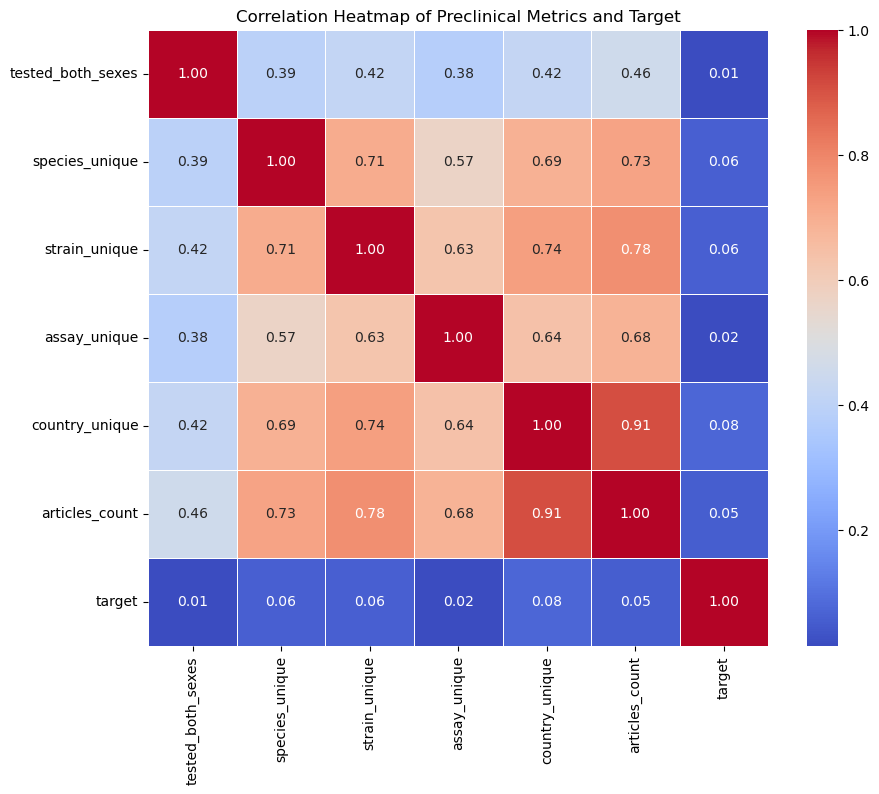

In [321]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Preclinical Metrics and Target')
plt.show()

In [322]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization
from sklearn.preprocessing import StandardScaler # better without this -> bad for the binary variable, std dev of binary variable does not make sense
df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

# Standardize (important for comparing coefficients)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit model
model = LogisticRegression()
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.182121
strain_unique        0.040040
tested_both_sexes   -0.027380
assay_unique        -0.067121
dtype: float64


In [323]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization
from sklearn.preprocessing import StandardScaler # better without this -> bad for the binary variable, std dev of binary variable does not make sense
# exp = odds ratio when i increase species by one
# idea: table with p-values and confidence intervals -> summary of the GLM fit -> 
# model selection -> cross validation
# missing data -> is it systematic? if it is related to a variable that has been collected it could be imputed -> try to omit missing ones
# forest plot for the coeff -> estimates + confidence interval (p-value); also case with multilpe imputations -> sensitivity analysis -> MICE package in R -> only if NOT "missing not at random"
# dorest plot at loggs ratio scale-> what increases/ decreases success -> conf interval!!
# check forest plot packages in R -> point estimate, conf interval, variable names -> give GLM object, get forest 

df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

# Standardize (important for comparing coefficients)
scaler = StandardScaler()
X_scaled = X.copy()

# Fit model
model = LogisticRegression()
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.179474
strain_unique        0.010181
assay_unique        -0.048800
tested_both_sexes   -0.055044
dtype: float64


In [324]:
from sklearn.linear_model import LogisticRegression # does it use regularization/ penalty by default? -> should be without penalization

df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

X_scaled = X.copy()

# Fit model
model = LogisticRegression(
    penalty="none",
    solver="lbfgs",
    max_iter=1000
)
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.179739
strain_unique        0.010171
assay_unique        -0.048843
tested_both_sexes   -0.055230
dtype: float64


/home/sdonev/data/conda/envs/torch-huggingface/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1182: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


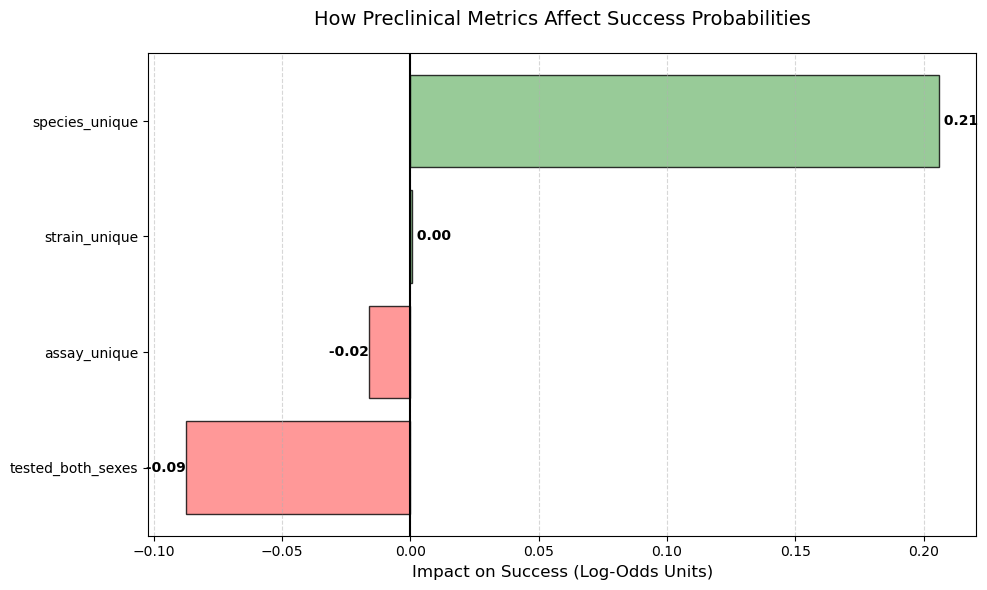

In [325]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the data
data = {
    'Feature': ['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes'],
    'Log-Odds': [0.205871, 0.000613, -0.016262, -0.087504]
}

df_importance = pd.DataFrame(data).sort_values(by='Log-Odds', ascending=True)

# 2. Create the plot
plt.figure(figsize=(10, 6))
# Use green for positive impact and red for negative
colors = ['#ff7f7f' if x < 0 else '#7fbf7f' for x in df_importance['Log-Odds']]
bars = plt.barh(df_importance['Feature'], df_importance['Log-Odds'], color=colors, edgecolor='black', alpha=0.8)

# 3. Add styling
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5) # Reference line at 0
plt.xlabel('Impact on Success (Log-Odds Units)', fontsize=12)
plt.title('How Preclinical Metrics Affect Success Probabilities', fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Label the bars with the actual values
for bar in bars:
    width = bar.get_width()
    label_x_pos = width if width > 0 else width
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f' {width:.2f}', 
             va='center', ha='left' if width > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_plot.png')

## Sample data for validation

In [326]:
sampled_df = pd.concat([
    all_entities[all_entities["target"] == 1].sample(n=5, random_state=42),
    all_entities[all_entities["target"] == 0].sample(n=5, random_state=42)
])
sampled_df

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_count,target
3807,major depressive disorder <> benzodiazepine,0,1,1,1,1,1,1
5108,toxic labyrinthitis <> thiosulfates,1,2,1,3,3,4,1
4241,obsolete disorder involving pain <> ibuprofen ...,0,1,1,3,1,1,1
2324,amyotrophic lateral sclerosis <> granulocyte c...,1,2,2,4,3,6,1
5058,substance-induced psychosis <> aripiprazole,0,1,1,1,1,1,1
544,cognitive disorder <> epigallocatechin gallate,0,2,1,4,2,2,0
1986,substance dependence <> propranolol,0,1,1,1,1,1,0
420,carpal tunnel syndrome <> triamcinolone,0,1,1,3,1,1,0
527,cocaine dependence <> cocaethylene,0,1,0,1,1,1,0
196,arteriosclerosis disorder <> 1-(5-isoquinoline...,0,1,1,2,1,1,0


In [327]:
numeric_cols = [
    "tested_both_sexes",
    "species_unique",
    "strain_unique",
    "assay_unique",
    "country_unique",
]

# compute z-scores
z_scores = (
    all_entities[numeric_cols]
    .apply(lambda x: (x - x.mean()) / x.std())
    .abs()
)

# mark outliers (any column with z > 2.5)
outliers = all_entities[z_scores.max(axis=1) > 2.5]

outlier_sample = outliers.sample(n=5, random_state=42)
outlier_sample

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_count,target
3347,epilepsy with generalized tonic-clonic seizure...,1,5,10,4,7,18,1
127,alzheimer disease <> ubidecarenone,1,2,13,5,11,21,0
3529,hiv infectious disease <> tenofovir,1,6,11,5,10,29,1
1766,schizophrenia <> amphetamine,1,5,30,5,16,70,0
2988,depressive disorder <> buspirone,1,2,11,4,14,33,1


In [328]:
combined_preclin_df.head()

,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
0,drug dependence <> cocaine,drug dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,Swiss,"[22.0, 27.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,failed,0,1,1,0
1,cocaine dependence <> cocaine,cocaine dependence,cocaine,21790900,Addictive potential of modafinil and cross-sen...,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,Swiss,"[22.0, 27.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,failed,0,1,1,0
2,drug dependence <> cocaine,drug dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,failed,0,0,0,0
3,cocaine dependence <> cocaine,cocaine dependence,cocaine,29227643,Structure-Activity Relationship Studies on a S...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,failed,0,0,0,0
4,drug dependence <> cocaine,drug dependence,cocaine,10485969,Rapid induction of behavioral and neurochemica...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,not reported,not reported,Molecular & Cellular,USA,failed,0,0,0,0


In [329]:
sampled_and_outliers_df = pd.concat([
    sampled_df,
    outlier_sample
])
sampled_and_outliers_df

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,articles_count,target
3807,major depressive disorder <> benzodiazepine,0,1,1,1,1,1,1
5108,toxic labyrinthitis <> thiosulfates,1,2,1,3,3,4,1
4241,obsolete disorder involving pain <> ibuprofen ...,0,1,1,3,1,1,1
2324,amyotrophic lateral sclerosis <> granulocyte c...,1,2,2,4,3,6,1
5058,substance-induced psychosis <> aripiprazole,0,1,1,1,1,1,1
544,cognitive disorder <> epigallocatechin gallate,0,2,1,4,2,2,0
1986,substance dependence <> propranolol,0,1,1,1,1,1,0
420,carpal tunnel syndrome <> triamcinolone,0,1,1,3,1,1,0
527,cocaine dependence <> cocaethylene,0,1,0,1,1,1,0
196,arteriosclerosis disorder <> 1-(5-isoquinoline...,0,1,1,2,1,1,0


In [330]:
out_dir="./data/translation_validation"
def safe_filename(s: str) -> str:
    s = s.strip()
    s = re.sub(r"[^\w\-<> ]+", "", s)
    s = s.replace(" <> ", "_")
    s = re.sub(r"\s+", "_", s)
    return s[:200]

# df_drugs must contain: drug_name, target
for _, row in (
    sampled_and_outliers_df[["drug_name", "target"]]
    .dropna()
    .drop_duplicates()
    .iterrows()
):
    key = row["drug_name"]
    target = int(row["target"])

    prefix = "positive_" if target == 1 else "negative_"

    sub = combined_preclin_df[
        combined_preclin_df["normalized_key"] == key
    ].copy()

    if sub.empty:
        continue
        

    if len(sub) > 5:
        sub = sub.sample(n=5, random_state=42)
        
    fname = prefix + safe_filename(key) + ".csv"
    path = os.path.join(out_dir, fname)

    sub.to_csv(path, index=False)

print(f"Saved per-drug CSVs with target prefix to: {out_dir}")

Saved per-drug CSVs with target prefix to: ./data/translation_validation


In [331]:
sampled_and_outliers_df.to_csv(out_dir+"/sampled_and_outliers_df.csv",index=False)

In [332]:
 combined_preclin_df[
        combined_preclin_df["normalized_key"] == "epilepsy <> phenytoin"
    ].to_csv(out_dir +"/epilepsy_phenytoin_all.csv",index=False)

In [333]:
combined_preclin_df[
    (combined_preclin_df["normalized_key"] == "focal epilepsy <> carbamazepine") &
    (combined_preclin_df["animal_species"].str.contains("dog"))
]


,normalized_key,merged_mondo_label,merged_umls_label,PMID,title,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_strain,animal_number,assay_type,first_author_country,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary


In [72]:
combined_preclin_df[
    (combined_preclin_df["normalized_key"] == "focal epilepsy <> carbamazepine")
].animal_species

19702       guinea pig
20333            mouse
20945              rat
21419              rat
21477              rat
21945              rat
22034              rat
22047       mouse, rat
22169            mouse
22177              rat
24222              rat
24225            mouse
24692           rabbit
24693              rat
24695      pig, rabbit
24696    species-other
24697              pig
Name: animal_species, dtype: object

In [39]:
combined_preclin_df[combined_preclin_df['PMID']==24878681]

,normalized_key,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label,study_classification
31101,brain ischemia <> sevoflurane,24878681,A combination of mild hypothermia and sevoflur...,brain hypoxia - ischemia|brain|perinatal asphyxia,sevoflurane,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"[19.0, 22.0, 29.0]","Behavioral, Histology, Molecular & Cellular, P...",USA,brain hypoxia - ischemia|brain|perinatal asphy...,sevoflurane,approved
31102,brain hypoxia - ischemia <> sevoflurane,24878681,A combination of mild hypothermia and sevoflur...,brain hypoxia - ischemia|brain|perinatal asphyxia,sevoflurane,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,mouse,not-reported,not reported,not reported,"[19.0, 22.0, 29.0]","Behavioral, Histology, Molecular & Cellular, P...",USA,brain hypoxia - ischemia|brain|perinatal asphy...,sevoflurane,approved


# Viz Drug-Disease Clinical x Preclinical

In [334]:
import os
import numpy as np
import matplotlib.pyplot as plt

def viz_joined_preclin_clinical(
    filtered_df,
    normalized_key="normalized_condition",
    additional_sort_by="both",
    translation_column=None,
    top_n=25,
    fig_name_suffix="",
    save_to="png",
    save_path="06_preclin_clinic_join/viz",
):
    """
    Visualizes the top N normalized conditions with:
      - Preclinical Count
      - Preclinical Count Before Clinical
      - Clinical Count
    as grouped horizontal bars.

    Adds ♦ and min_relevant_clinical_year next to clinical count if translation_column is True.
    """

    # --- select top N ---
    if additional_sort_by == "both":
        top_n_df = filtered_df.head(top_n)
        title_str = "Clinical + Preclinical Count"
    elif additional_sort_by == "clinical_count":
        top_n_df = filtered_df.sort_values(by="clinical_count", ascending=False).head(top_n)
        title_str = "Clinical Count"
    elif additional_sort_by == "tail":
        top_n_df = filtered_df.tail(top_n)
        title_str = "Clinical + Preclinical Count Tail"
    else:
        top_n_df = filtered_df.sort_values(by="preclinical_count", ascending=False).head(top_n)
        title_str = "Preclinical Count"

    conditions = top_n_df[normalized_key].astype(str)
    clinical_counts = top_n_df["clinical_count"].fillna(0)
    preclinical_counts = top_n_df["preclinical_count"].fillna(0)
    preclinical_before_clinical_counts = top_n_df["preclinical_count_before_clinical"].fillna(0)
    min_years = top_n_df.get("min_relevant_clinical_year")

    y_positions = np.arange(len(conditions))
    bar_width = 0.24

    os.makedirs(save_path, exist_ok=True)

    plt.figure(figsize=(14, 10))

    # Bars
    plt.barh(y_positions - bar_width, preclinical_counts, height=bar_width,
             label="Preclinical Count", color="#56B4E9", zorder=2)

    plt.barh(y_positions, preclinical_before_clinical_counts, height=bar_width,
             label="Preclinical Before Clinical", color="#009E73", zorder=2)

    plt.barh(y_positions + bar_width, clinical_counts, height=bar_width,
             label="Clinical Count", color="#E69F00", zorder=2)

    # Labels
    for i in range(len(conditions)):

        # Preclinical total
        plt.text(preclinical_counts.iloc[i],
                 y_positions[i] - bar_width,
                 f"{preclinical_counts.iloc[i]:.0f}",
                 va="center", fontsize=13)

        # Preclinical before clinical
        plt.text(preclinical_before_clinical_counts.iloc[i],
                 y_positions[i],
                 f"{preclinical_before_clinical_counts.iloc[i]:.0f}",
                 va="center", fontsize=13)

        # Clinical + optional diamond + year
        clinical_text = f"{clinical_counts.iloc[i]:.0f}"

        if translation_column and bool(top_n_df[translation_column].iloc[i]):
            year_str = ""
            if min_years is not None and not pd.isna(min_years.iloc[i]):
                year_str = f" {int(min_years.iloc[i])}"
            clinical_text += f" ♦{year_str}"

        plt.text(clinical_counts.iloc[i],
                 y_positions[i] + bar_width,
                 clinical_text,
                 va="center", fontsize=13)

    # Axis formatting
    plt.yticks(y_positions, conditions)
    plt.xlabel("Study Count", fontsize=15)
    plt.title(f"Top {top_n} Disease-Drug Pairs by {title_str}", fontsize=18)

    if translation_column:
        plt.legend(
            handles=[
                plt.Line2D([0], [0], color="#56B4E9", lw=6, label="Preclinical Count"),
                plt.Line2D([0], [0], color="#009E73", lw=6, label="Preclinical Before Clinical"),
                plt.Line2D([0], [0], color="#E69F00", lw=6, label="Clinical Count"),
                plt.Line2D([0], [0], color="black", marker="D", linestyle="",
                           label="At least one Phase 4 trial (♦ year shown)"),
            ],
            loc="lower right",
            fontsize=12,
        )
    else:
        plt.legend(loc="lower right", fontsize=12)

    plt.tick_params(axis="both", labelsize=12)
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.4, color="gray", zorder=0)

    plt.tight_layout()

    out_file = f"{save_path}/top{top_n}_preclin_clin{fig_name_suffix}.{save_to}"
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()


In [335]:
df_translated['translated']=True
df_failed['translated']=False

/tmp/ipykernel_3939435/1226866206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['translated']=True


In [337]:
df_combined_with_articles = pd.concat([df_failed, df_translated], axis=0, ignore_index=True)
df_combined_with_articles.shape

(10151, 36)

In [338]:
df_combined_with_articles["preclinical_count_before_clinical"] = (
    df_combined_with_articles["preclinical_count_before_clinical"]
    .fillna(df_combined_with_articles["preclinical_count_before_latest_trial"])
)


In [339]:
df_combined_with_articles_to_merge = df_combined_with_articles[['normalized_key','preclinical_count_before_clinical','translated','min_relevant_clinical_year']]
translation_table_for_viz = translation_table.merge(df_combined_with_articles_to_merge, left_on="normalized_key", right_on="normalized_key",how="left")

In [340]:
translation_table_for_viz.shape

(13570, 34)

In [341]:
translation_table_for_viz[translation_table_for_viz.normalized_key.str.contains("parkinson disease <> levodopa")]

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,translation_status,min_relevant_clinical_year_x,preclinical_count_before_clinical,translated,min_relevant_clinical_year_y
0,parkinson disease <> levodopa,"['NCT00004576', 'NCT00006077', 'NCT00006337', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 2000.0, 2000.0, 2001.0, 2001.0, 2002....","[2000.0, 2003.0, 2002.0, 2003.0, 2005.0, 2005....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,1975.0,parkinson's disease; parkinson’s disease,"['ANDA073589', 'ANDA073607', 'ANDA073618', 'AN...",parkinson disease <> levodopa,True,approved,1975,4.0,True,1975
45,late-onset parkinson disease <> levodopa,"['NCT00009048', 'NCT00013624', 'NCT00040209', ...",MONDO:0008199,C0023570,late-onset parkinson disease,levodopa,"[2001.0, 2001.0, 2002.0, 2004.0, 2004.0, 2005....","[2003.0, 2005.0, 2005.0, 2005.0, 2007.0, nan, ...","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,NaN,NaN,NaN,NaN,False,approved,2005,0.0,True,2005
229,young-onset parkinson disease <> levodopa,"['NCT00096720', 'NCT00134784', 'NCT00134966', ...",MONDO:0017279,C0023570,young-onset parkinson disease,levodopa,"[2004.0, 2000.0, 2005.0, 2005.0, 2005.0, 2007....","[2007.0, 2007.0, 2007.0, 2009.0, 2008.0, 2012....","['Phase 2', 'Phase 2', 'Phase 3', 'Phase 4', '...","['Completed', 'Completed', 'Completed', 'Compl...",...,NaN,NaN,NaN,NaN,False,approved,2005,2.0,True,2005
3611,parkinson disease <> levodopa benserazide,"['NCT02741947', 'NCT06115538']",MONDO:0005180,-1,parkinson disease,levodopa benserazide,"[2014.0, 2023.0]","[2015.0, 2025.0]","['Phase 4', 'Phase 4']","['Completed', 'Enrolling by invitation']",...,NaN,NaN,NaN,NaN,False,approved,2014,6.0,True,2014
9861,parkinson disease <> levodopa/benserazide,['NCT02741947'],MONDO:0005180,-1,parkinson disease,levodopa/benserazide,[2014.0],[2015.0],['Phase 4'],['Completed'],...,NaN,NaN,NaN,NaN,False,approved,2014,1.0,True,2014
10625,autosomal dominant parkinson disease <> levodopa,['NCT00947037'],MONDO:0008200,C0023570,autosomal dominant parkinson disease,levodopa,[2012.0],[nan],['Phase 2'],['Withdrawn'],...,NaN,NaN,NaN,NaN,False,failed,<NA>,0.0,False,2012


In [342]:
translation_table_for_viz[translation_table_for_viz['translated']==False]

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,trial_completion_year,phase,overall_status,...,fda_earliest_year,fda_disease,fda_documents,fda_disease<>drug,fda_AP,translation_status,min_relevant_clinical_year_x,preclinical_count_before_clinical,translated,min_relevant_clinical_year_y
80,drug dependence <> cocaine,"['NCT00032916', 'NCT00033059', 'NCT00033098', ...",MONDO:0005303,C0009170,drug dependence,cocaine,"[2001.0, 2001.0, 2001.0, 2003.0, 2003.0, 2004....","[2002.0, 2002.0, 2002.0, 2005.0, nan, 2005.0, ...","['Phase 1', 'Phase 1', 'Phase 1', 'Phase 1', '...","['Unknown status', 'Unknown status', 'Unknown ...",...,NaN,NaN,NaN,NaN,False,failed,<NA>,35.0,False,2018
98,cocaine dependence <> cocaine,"['NCT00032916', 'NCT00033059', 'NCT00033098', ...",MONDO:0005186,C0009170,cocaine dependence,cocaine,"[2001.0, 2001.0, 2001.0, 2003.0, 2003.0, 2004....","[2002.0, 2002.0, 2002.0, 2005.0, nan, 2005.0, ...","['Phase 1', 'Phase 1', 'Phase 1', 'Phase 1', '...","['Unknown status', 'Unknown status', 'Unknown ...",...,NaN,NaN,NaN,NaN,False,failed,<NA>,33.0,False,2018
100,brain neoplasm <> temozolomide,"['NCT00005812', 'NCT00006024', 'NCT00034697', ...",MONDO:0021211,C0076080,brain neoplasm,temozolomide,"[2000.0, 2000.0, 2001.0, 2004.0, 2004.0, 2006....","[2004.0, 2006.0, 2003.0, 2006.0, 2013.0, 2014....","['Phase 2', 'Phase 1', 'Phase 2', 'Phase 2', '...","['Terminated', 'Completed', 'Terminated', 'Com...",...,NaN,NaN,NaN,NaN,False,failed,<NA>,122.0,False,2023
221,brain neoplasm <> bevacizumab,"['NCT00312728', 'NCT00463203', 'NCT00597402', ...",MONDO:0021211,C0796392,brain neoplasm,bevacizumab,"[2006.0, 2007.0, 2007.0, 2008.0, 2008.0, 2009....","[2009.0, 2011.0, 2013.0, 2014.0, 2015.0, 2010....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 1', '...","['Completed', 'Completed', 'Completed', 'Termi...",...,NaN,NaN,NaN,NaN,False,failed,<NA>,9.0,False,2020
244,obsolete disorder involving pain <> dronabinol,"['NCT00176163', 'NCT00552604', 'NCT01608217', ...",MONDO:0021668,C0039663,obsolete disorder involving pain,dronabinol,"[2005.0, 2006.0, 2012.0, 2015.0, 2020.0, 2021....","[2009.0, 2008.0, 2014.0, 2019.0, 2020.0, 2025....","['Phase 2', 'Phase 3', 'Phase 2', 'Not Applica...","['Completed', 'Terminated', 'Completed', 'Unkn...",...,NaN,NaN,NaN,NaN,False,failed,<NA>,29.0,False,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13543,vestibular migraine <> migraine,['NCT02169830'],-1,-1,vestibular migraine,migraine,[2014.0],[2019.0],['Not Applicable'],['Terminated'],...,NaN,NaN,NaN,NaN,False,failed,<NA>,0.0,False,2014
13547,voiding dysfunction <> prazosin,['NCT00602186'],-1,C0032912,voiding dysfunction,prazosin,[2005.0],[2008.0],['Phase 1/Phase 2'],['Unknown status'],...,NaN,NaN,NaN,NaN,False,failed,<NA>,1.0,False,2005
13552,west nile fever <> mgawn1,['NCT00927953'],MONDO:0002282,-1,west nile fever,mgawn1,[2009.0],[2011.0],['Phase 2'],['Terminated'],...,NaN,NaN,NaN,NaN,False,failed,<NA>,0.0,False,2009
13559,x-linked cerebral adrenoleukodystrophy <> eruc...,['NCT00545597'],MONDO:0010247,C0014723,x-linked cerebral adrenoleukodystrophy,erucic acids,[2005.0],[2007.0],['Phase 3'],['Terminated'],...,NaN,NaN,NaN,NaN,False,failed,<NA>,0.0,False,2005


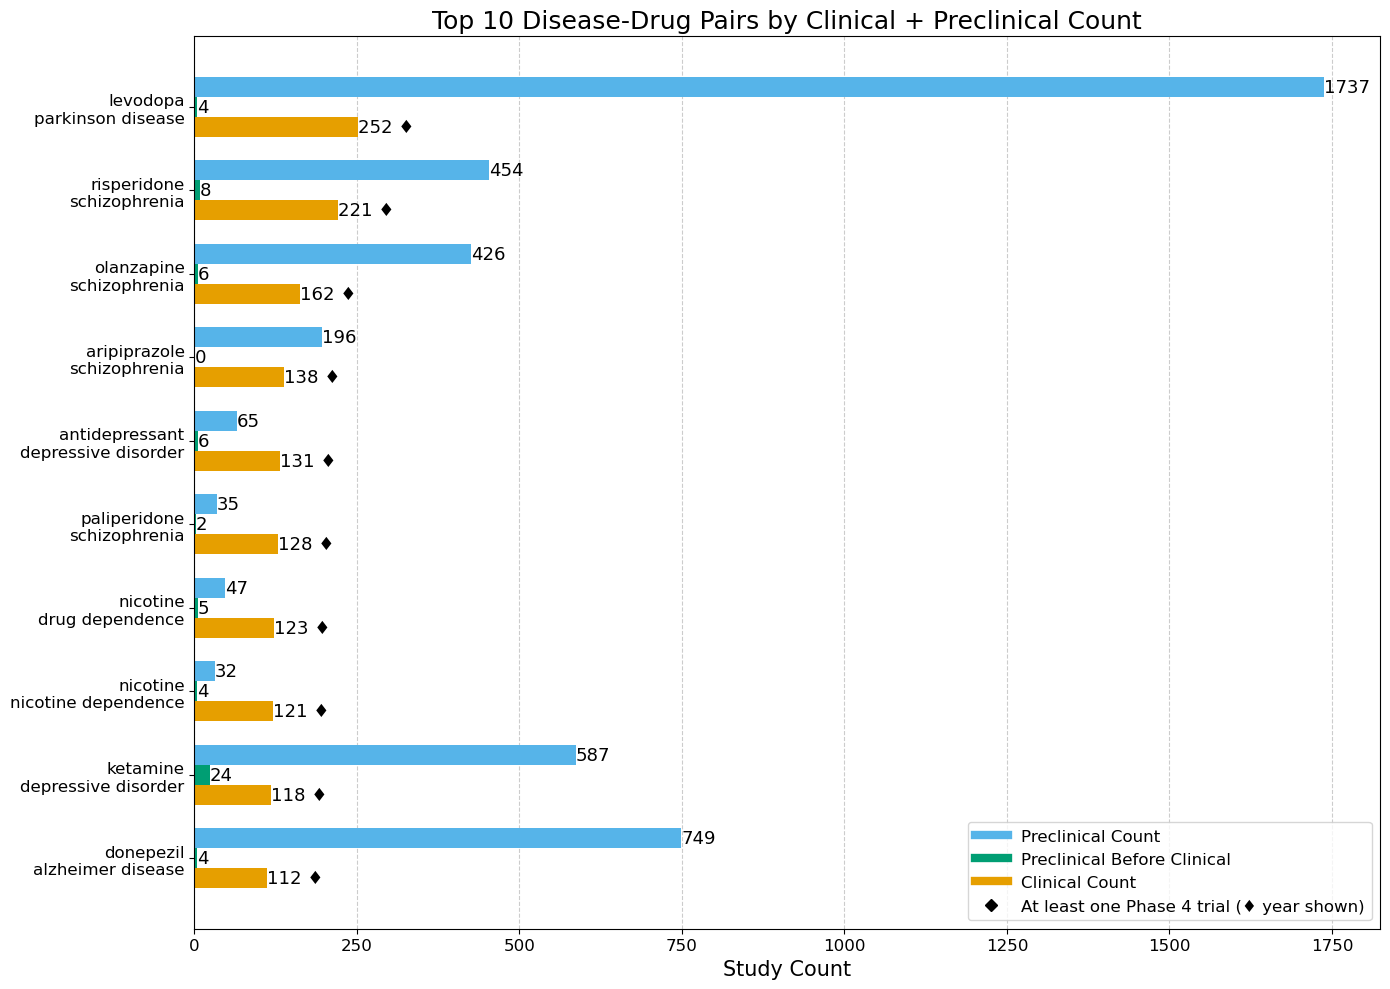

In [343]:
# ------------------------- #
#         VISUALIZE         #
# ------------------------- #
translation_table_for_viz['key_for_viz'] = (
    translation_table_for_viz['merged_umls_label'] + "\n" + translation_table_for_viz['merged_mondo_label']
)
all_entities_for_regression['key_for_viz'] = (
    all_entities_for_regression['merged_umls_label'] + "\n" + all_entities_for_regression['merged_mondo_label']
)
viz_joined_preclin_clinical(
    translation_table_for_viz,
    "key_for_viz",
    translation_column='translated',
    top_n=10,
    fig_name_suffix='',
    save_path="viz/"
)


In [344]:
translation_table_for_viz.translated.value_counts()

translated
True     5899
False    4252
Name: count, dtype: int64

In [346]:
translation_table_for_viz["translated"] = (
    translation_table_for_viz["translated"]
        .replace({True: "translated", False: "not translated",
                  "True": "translated", "False": "not translated"})
        .fillna("unknown")
)
plot_df = translation_table_for_viz.dropna(
    subset=["min_relevant_clinical_year_y", "preclinical_count_before_clinical"]
).copy()
plot_df.translated.value_counts()

translated
translated        5874
not translated    4252
Name: count, dtype: int64

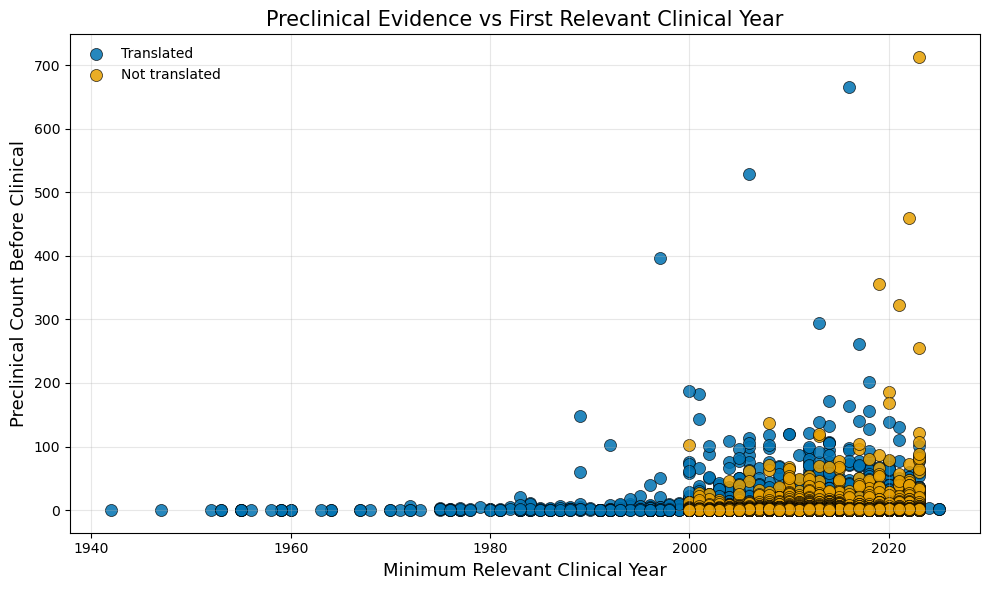

In [348]:



plt.figure(figsize=(10, 6))

# Okabe–Ito colorblind-safe palette
color_map = {
    "translated": "#0072B2",      # blue
    "not translated": "#E69F00",  # orange
    "unknown": "#999999"          # neutral grey
}

# Fixed legend order
for status in ["translated", "not translated", "unknown"]:
    subset = plot_df[plot_df["translated"] == status]

    if len(subset) == 0:
        continue

    plt.scatter(
        subset["min_relevant_clinical_year_y"],
        subset["preclinical_count_before_clinical"],
        color=color_map[status],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.85,
        s=75,
        label=status.capitalize()
    )

plt.xlabel("Minimum Relevant Clinical Year", fontsize=13)
plt.ylabel("Preclinical Count Before Clinical", fontsize=13)
plt.title("Preclinical Evidence vs First Relevant Clinical Year", fontsize=15)

plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()